**CAP 4773: Homework Assignment 8**

**Due on Canvas by Monday, December 1, 2025 at 11:59pm**



**Place name here:** Alex Wagner

**Preliminary instructions**

All analyses must be performed in Python using only the **`plotnine`**, **`tidypandas`**, **`statsmodels.api`**, and **`sklearn`** libraries that we discussed in class. You may *not* use **`pandas`**, **`matplotlib`**, or **`seaborn`**. The only exception is that **`pandas`** may only be used to read an input file for your dataset. Fill in all your solutions in the appropriate text or code cells provided in this Python notebook, and then upload a HTML-converted copy of your Python notebook solution to Canvas. **Only HTML copies of this notebook will be graded.** Instructions on how to convert Python notebooks to HTML in Google Colab are provided at the bottom of this assignment.

Install all libraries and necessary dependencies below.

Load all necessary libraries below.

In [1]:
import numpy as np
import pandas as pd 
from tidypandas import tidyframe 
from plotnine import * 
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

**Brief overview of assignment**

In this assignment you will be tasked with identifying a dataset from an external source, and apply visualization, transformation, and supervised and unsupervised modeling to your identified dataset. You will also need to effectively communicate your findings.

There are many websites that you can obtain datasets suitable for analysis. One such site is kaggle: **`https://www.kaggle.com/datasets`**.

You may of course use other reputable sites to obtain your dataset, but you may not use a dataset that we have already covered in class, either during lecture or in the homework assignments.

**Grading**

Grading will be based on adherenence to formatting and content requirements, as well as on effective communication. Points will be deducted for any perceived attempts to circumvent requirements. Ensure that all visualizations are clear and of professional quality, noting that all axes must be labeled in detail. A key goal of this final assignment is to effectively communicate findings, and visualization can impart the opposite effect if it is unclear.

**1. [5%]** Provide the name and website address of the dataset that you chose to analyze.

**Provide response here:** 
MAL Anime dataset: https://www.kaggle.com/datasets/alexeiluchian/mal-anime-dataset

**2. [5%]** Provide code to import your dataset and store as a data frame below, and describe your dataset in terms of the number of observations, number of features, and the number of each type of feature (*e.g.*, categorical and continuous).

In [2]:
df = pd.read_csv("anime_dataset.csv")
tdf = tidyframe(df)
tdf


c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\tidy_utils.py:211: FutureWarning: RangeIndex.is_numeric is deprecated. Use pandas.api.types.is_any_real_numeric_dtype instead
c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\format.py:166: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.


,title,score,genres,episodes,synopsis,popularity,members,studios,year
,<object>,<float64>,<object>,<float64>,<object>,<int64>,<int64>,<object>,<float64>
0,Attack on Titan,8.57,"['Action', 'Award Winning', 'Drama', 'Suspense...",25.0,"Centuries ago, mankind was slaughtered to near...",1,4245518,['Wit Studio'],2013.0
1,Death Note,8.62,"['Supernatural', 'Suspense', 'Psychological', ...",37.0,"Brutal murders, petty thefts, and senseless vi...",2,4186098,['Madhouse'],2006.0
2,Fullmetal Alchemist: Brotherhood,9.10,"['Action', 'Adventure', 'Drama', 'Fantasy', 'M...",64.0,After a horrific alchemy experiment goes wrong...,3,3588803,['Bones'],2009.0
3,One-Punch Man,8.48,"['Action', 'Comedy', 'Adult Cast', 'Parody', '...",12.0,The seemingly unimpressive Saitama has a rathe...,4,3443899,['Madhouse'],2015.0
4,Demon Slayer: Kimetsu no Yaiba,8.42,"['Action', 'Award Winning', 'Supernatural', 'H...",26.0,"Ever since the death of his father, the burden...",5,3340293,['ufotable'],2019.0
5,Sword Art Online,7.22,"['Action', 'Adventure', 'Fantasy', 'Romance', ...",25.0,Ever since the release of the innovative Nerve...,6,3240244,['A-1 Pictures'],2012.0
6,My Hero Academia,7.83,"['Action', 'School', 'Super Power', 'Shounen']",13.0,"The appearance of ""quirks,"" newly discovered s...",7,3223923,['Bones'],2016.0
7,Hunter x Hunter,9.03,"['Action', 'Adventure', 'Fantasy', 'Shounen']",148.0,Hunters devote themselves to accomplishing haz...,8,3093558,['Madhouse'],2011.0
8,Naruto,8.01,"['Action', 'Adventure', 'Fantasy', 'Martial Ar...",220.0,"Twelve years ago, a colossal demon fox terrori...",9,3045026,['Studio Pierrot'],2002.0


**Provide response here:** 9 features and 1050 observations. 
title: categorial
score: continouous 
genres: categorial
episodes: continuous
synopsis: description?
popularity: integer ranking
members: continious
studios: categorial
year: year, integer


**3. [40%]** Explore your dataset, which includes visualization, transformation, and modeling to uncover patterns and generate testable hypotheses. Add as many code and text boxes below to demonstrate a rigorous, open-ended exploration of your dataset. You must apply visualization, transformation, and modeling at least once here during your exploration, and in at least three separate stages (*e.g.*, it is not an exploration if you peform transformation and visualization together without visualizing your dataset before transformation). Note that credit will be based on how comprehensive you are in your exploration.

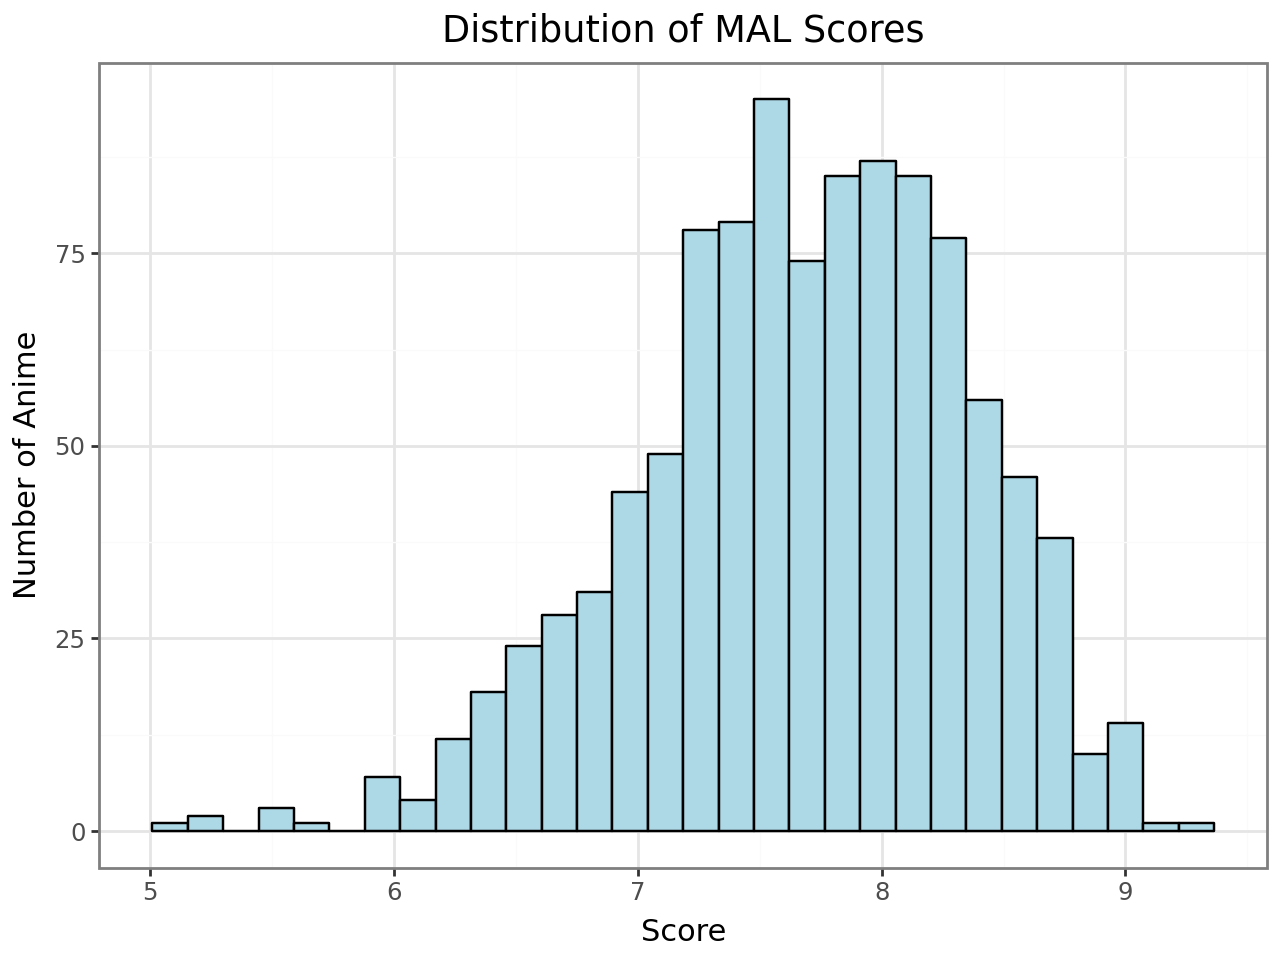

In [3]:
x = tdf.select("score") # Histogram of MAL score distribution

(ggplot(tdf, aes(x="score"))
 + geom_histogram(bins=30, color="black", fill="lightblue")
 + labs(title="Distribution of MAL Scores",
        x="Score",
        y="Number of Anime")
 + theme_bw()
) # The distro is left skewed. The tail on the left is longer

This histogram shows the score distribution of all anime scroes.

The data is left skewed. As seen the left tail of the bins are  longer. Most anime is between 7 and 8. MAL has a thing where most anime is average around 7-8 anyways

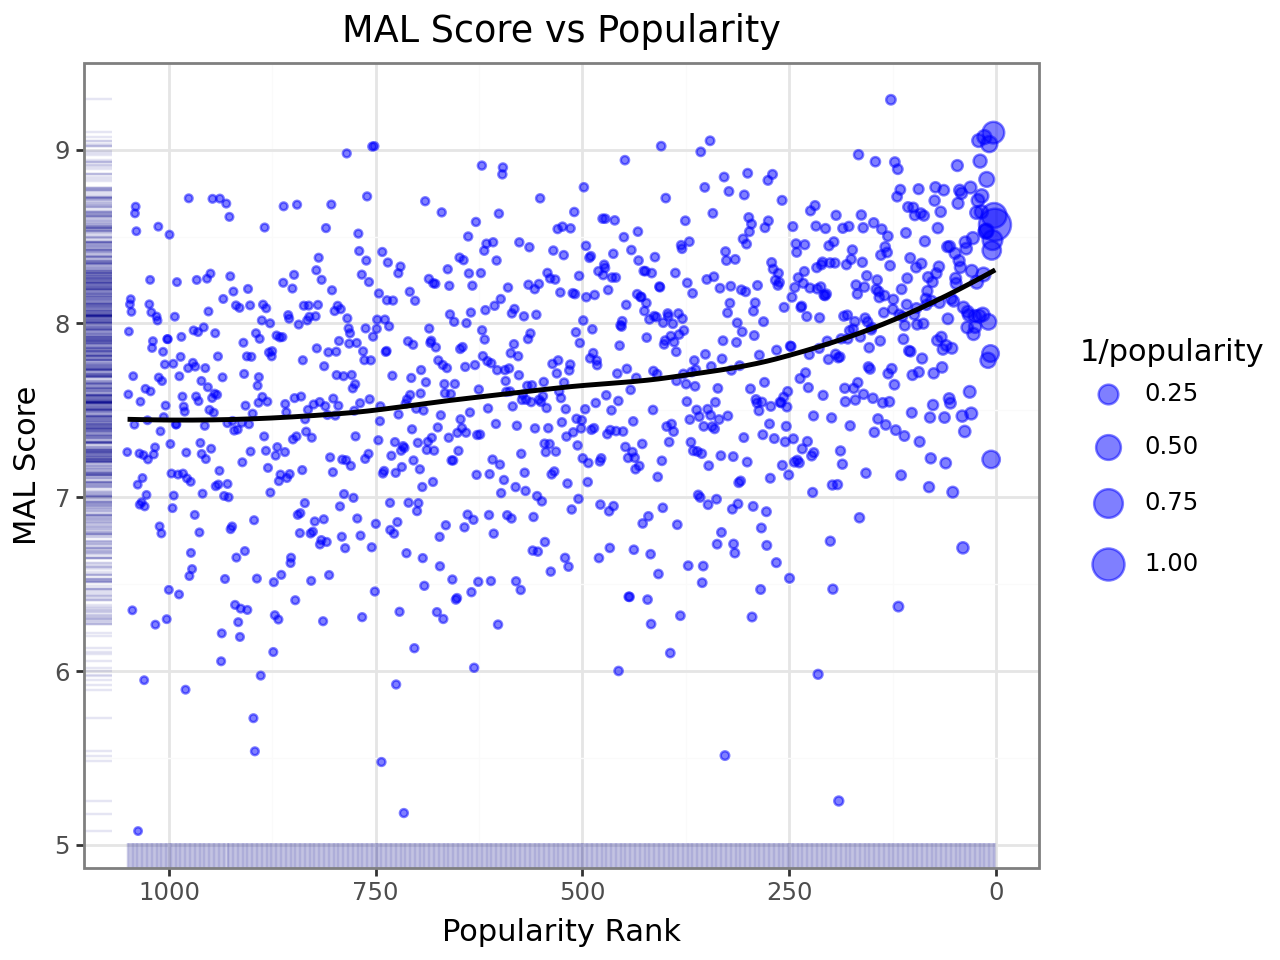

In [4]:
(ggplot(tdf, aes(x="popularity", y="score"))
 + geom_jitter(aes(size="1/popularity"), alpha=0.5, color="blue")
 + labs(title="MAL Score vs Popularity",
        x="Popularity Rank",
        y="MAL Score")
 + theme_bw()
 + geom_smooth(method="loess", color="black", se=False)
 + scale_x_reverse() # flips axis. Lower popularity rank = more popular
 + geom_rug(alpha=0.1, color="darkblue")
 + scale_size_continuous(range=[1,6])   
)


This scatterplot shows the scatter of all anime scores based on its popularity. There is a decent amount of noise here. But there is a slight upwards trend. More popular anime seem to have a higher score.

c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\tidyframe_class.py:1054: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotnine\geoms\geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.
c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotnine\layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


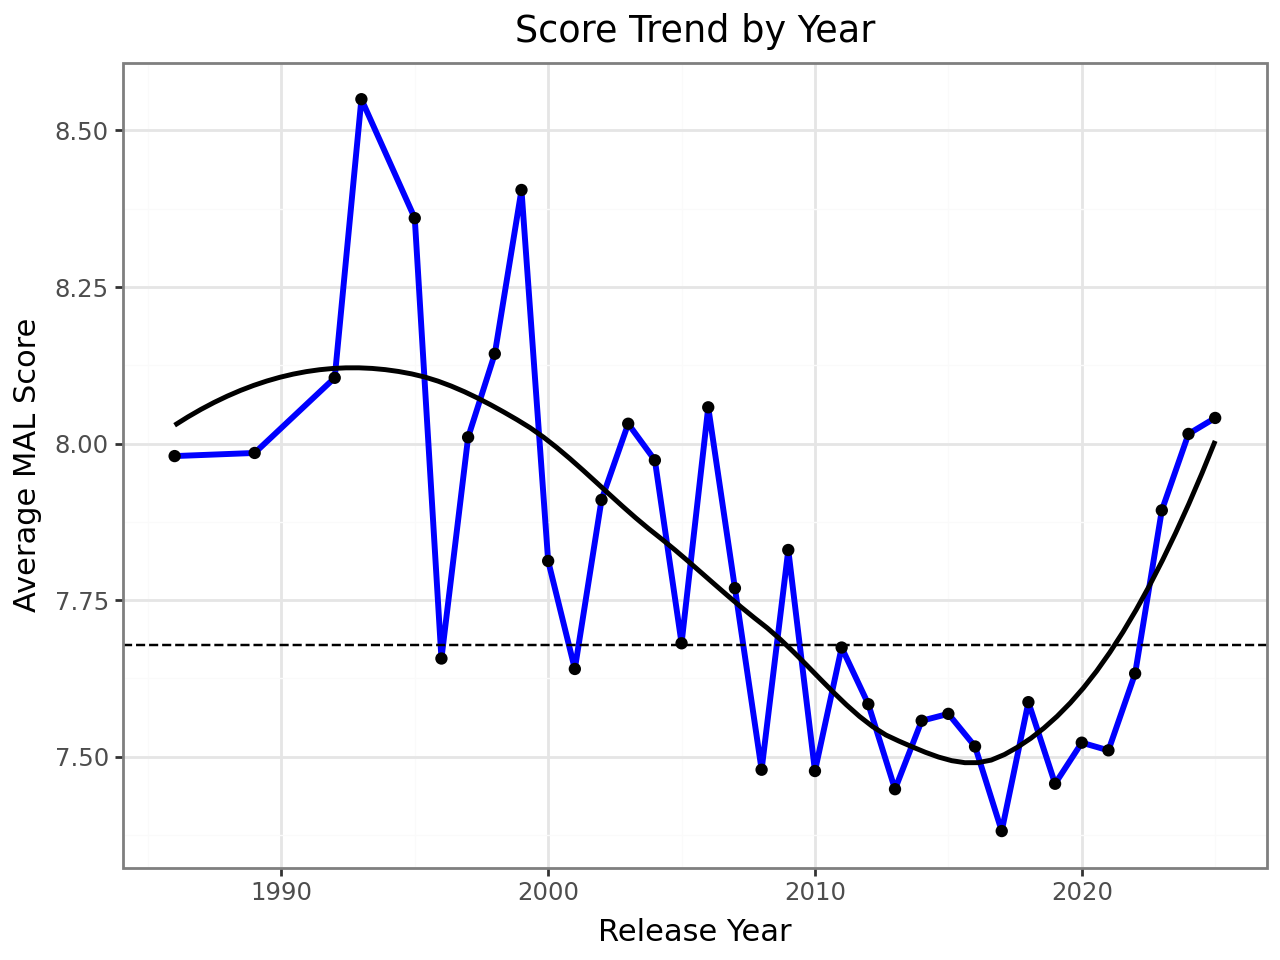

In [5]:
average_Score_by_year = tdf.summarize({
    "avg_score": "x['score'].mean()"
}, by=["year"])

(
    ggplot(average_Score_by_year, aes(x="year", y="avg_score"))
    + geom_line(color="blue", size=1.2)
    + geom_smooth(method="loess", se=False)
    + geom_point()
    + geom_hline(yintercept=tdf.pull("score").mean(), linetype="dashed")
    + labs(title="Score Trend by Year",
           x="Release Year",
           y="Average MAL Score")
    + theme_bw()
)


This line chart shows the shows the average score trend by years released. The trend goes downward until mid 2010s until it goes up again. The dashed line represents the overall average score across all years.

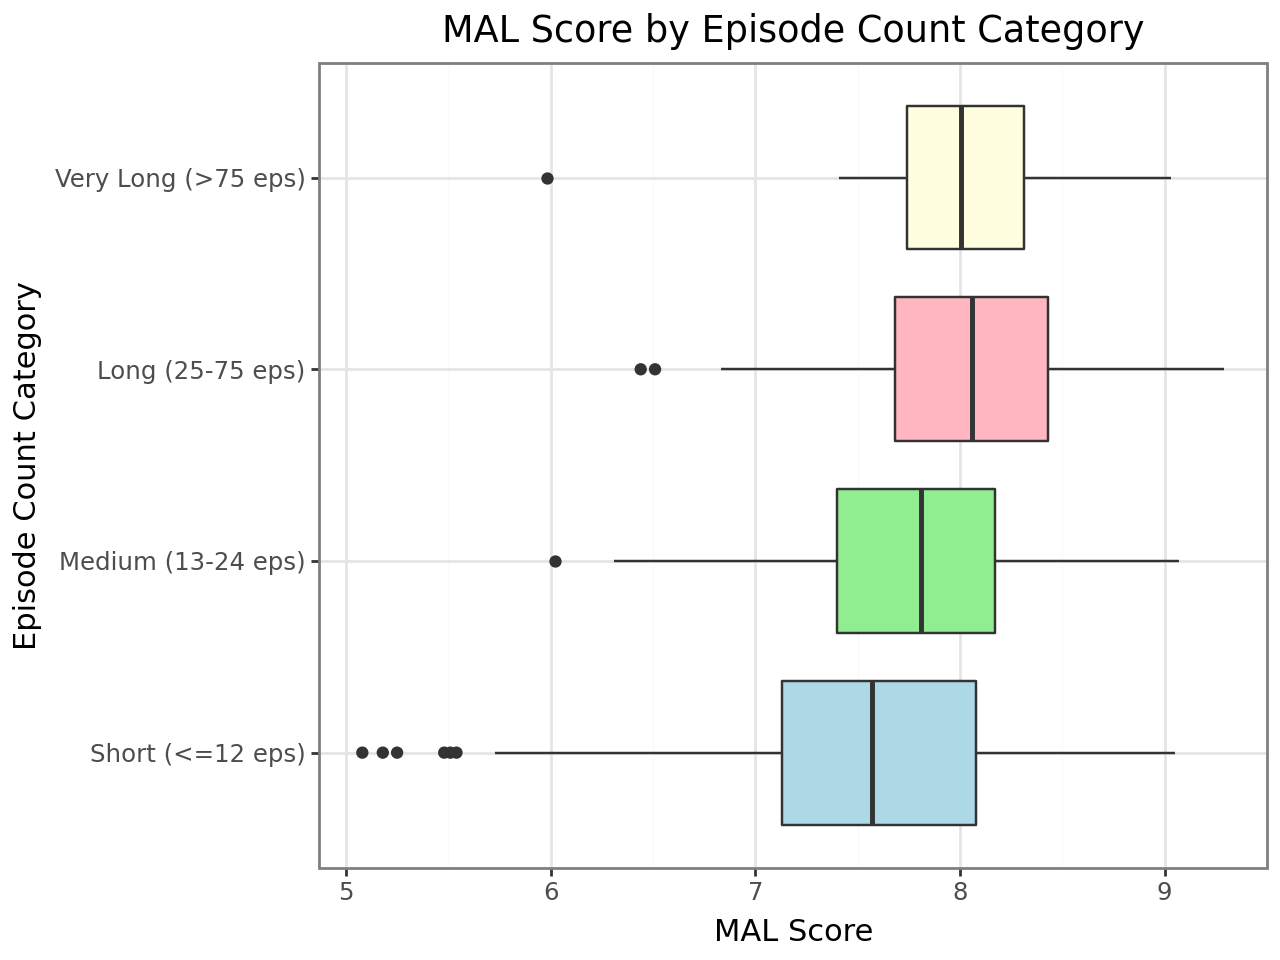

In [6]:
short_eps = tdf.filter(lambda x: x.episodes <= 12)
medium_eps = tdf.filter(lambda x: (x.episodes > 12) & (x.episodes <= 24))
long_eps = tdf.filter(lambda x: (x.episodes > 24) & (x.episodes <= 75))
very_long_eps = tdf.filter(lambda x: x.episodes > 75)

(ggplot() 
    + geom_boxplot(aes(y="score", x="'Short (<=12 eps)'"), data=short_eps, fill="lightblue")
    + geom_boxplot(aes(y="score", x="'Medium (13-24 eps)'"), data=medium_eps, fill="lightgreen")
    + geom_boxplot(aes(y="score", x="'Long (25-75 eps)'"), data=long_eps, fill="lightpink")
    + geom_boxplot(aes(y="score", x="'Very Long (>75 eps)'"), data=very_long_eps, fill="lightyellow")
    + labs(title="MAL Score by Episode Count Category",
           x="Episode Count Category",
           y="MAL Score")
    
    
    + theme_bw()
    + coord_flip()
    
)

These boxplots show the longer the anime, the shorter the distro of scores, and higher the median score. Short animes have a wider range of scores.

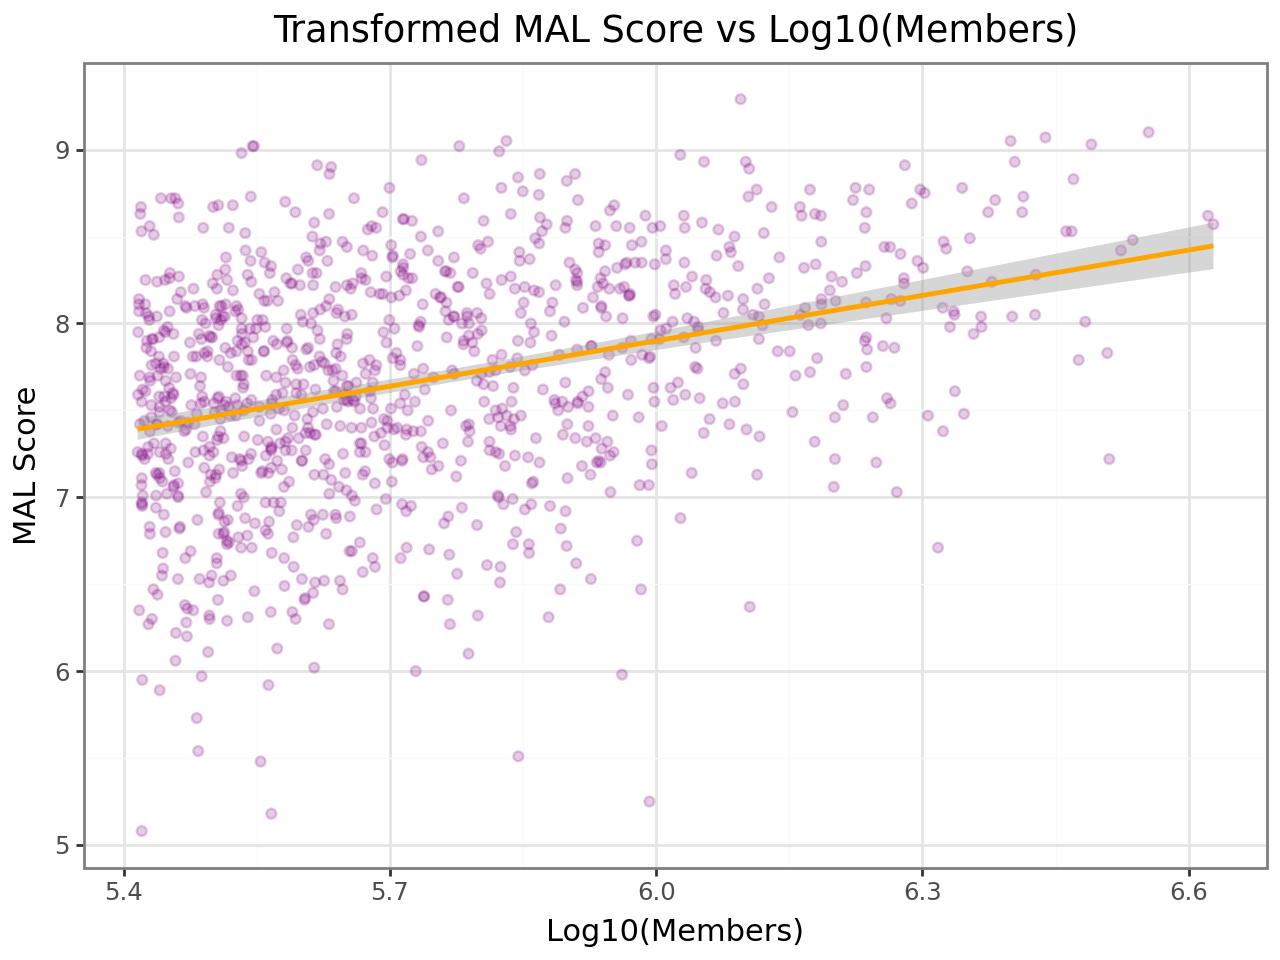

In [7]:
transformed_tdf = tdf.mutate({
    "log10members": lambda x: np.log10(x["members"])
})

(ggplot(transformed_tdf, aes(x="log10members", y="score"))
 + geom_point(alpha=0.2, color="purple")
 + geom_smooth(method="lm", color="orange", size=1)
 + labs(title="Transformed MAL Score vs Log10(Members)", 
        x="Log10(Members)", 
        y="MAL Score")
 + theme_bw()
)

This scatterplot shows a positive linear relatinship. Members are huge so its been cut down using log10 transformation.
It appears the more members an anime has, the higher its score tends to be, although the relationship is not very strong.

In [8]:
x = transformed_tdf.select("log10members").to_pandas()
y = transformed_tdf.select("score").to_pandas()

x_with_ones = sm.add_constant(x)
model = sm.OLS(y, x_with_ones).fit()
print(model.summary())
print("This indicates a significant positive correlation between log10(members) and MAL score, suggesting that more popular anime tend to have higher scores on average.")

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     138.7
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           3.65e-30
Time:                        20:46:42   Log-Likelihood:                -1000.2
No. Observations:                1050   AIC:                             2004.
Df Residuals:                    1048   BIC:                             2014.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.6800      0.425      6.308   

c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\tidy_utils.py:211: FutureWarning: RangeIndex.is_numeric is deprecated. Use pandas.api.types.is_any_real_numeric_dtype instead


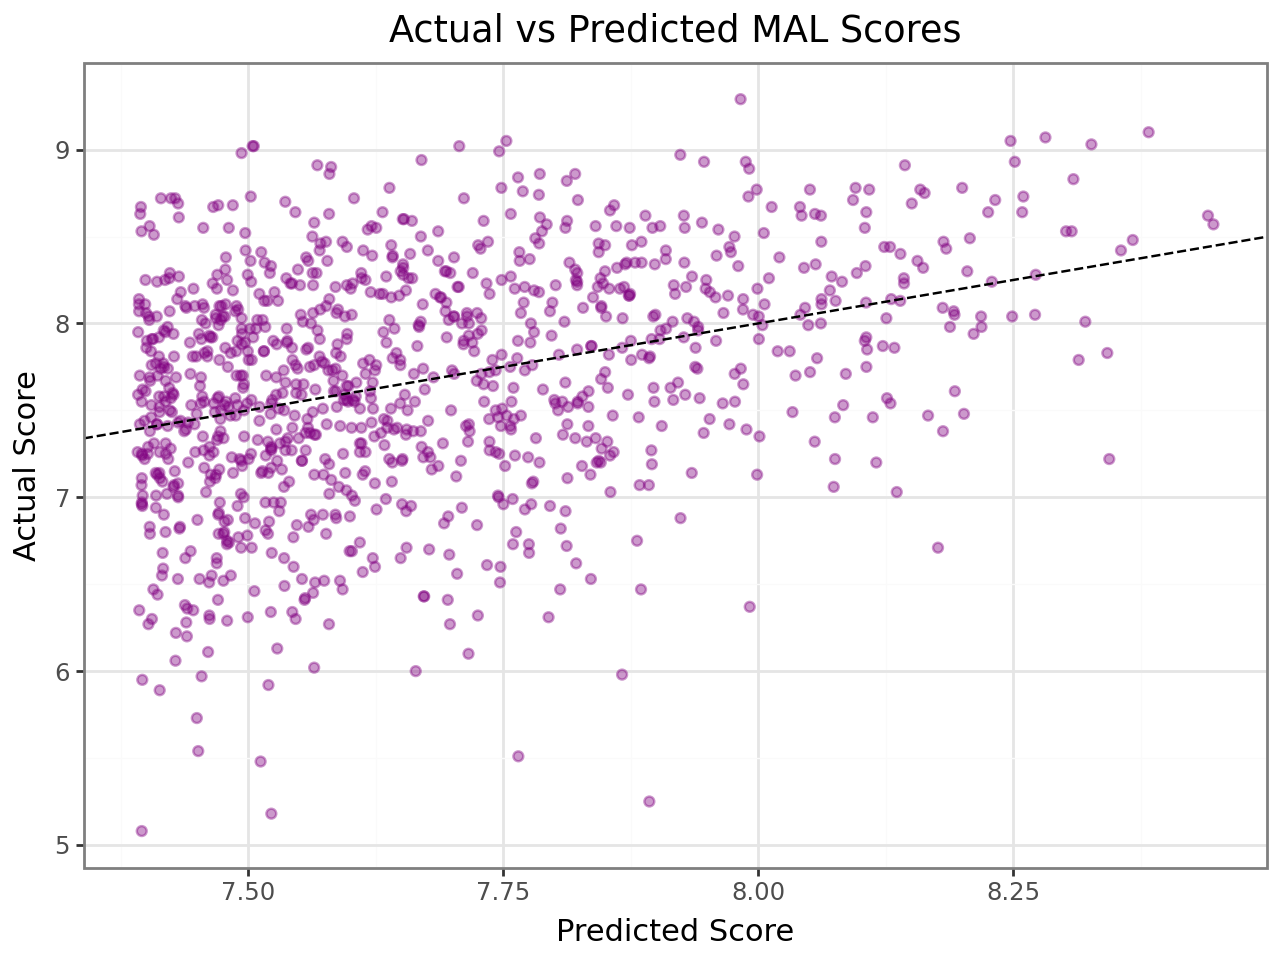

In [9]:
predictions = model.predict(x_with_ones)
new_tdf = tidyframe({
    "predictions": predictions,
    "actual_scores": y["score"]
})

(
    ggplot(new_tdf, aes(x="predictions", y="actual_scores"))
    + geom_point(alpha=0.4, color="purple")
    + geom_abline(intercept=0, slope=1, linetype="dashed")
    + labs(
        title="Actual vs Predicted MAL Scores",
        x="Predicted Score",
        y="Actual Score"
    )
    + theme_bw()
)



Wow, lots of scatterplots, last one i promise. This one is actual vs predicted MAL scores from the regression model above. The dashed line represents perfect prediction. Points closer to this line indicate better model performance.

**4. [40%]** Now that you've explored your dataset, embark on some additional modeling. You must perform at least one hypothesis test, supervised predictive modeling, and unsupervised learning to understand the structure of your dataset. For the hypothsis testing, you must clearly state your hypothesis or hypotheses (null and alternative hypotheses), the statistical tests used to asses your hypothesis or hypotheses, and what the conclusions are of the hypothesis test or tests. This will also include what the response variable is, and why you used specific modeling frameworks for the nature of this output variable. Add as many code and text boxes below as necessary for each hypothesis test, supervised predictive modeling, and unsupervised learning analysis, where each analysis must include a text description and conclusions drawn from it. Ensure that where appropriate, visualizations are included (see prior homework assignments and lecture notes for examples). Note that credit will be based on how comprehensive you are in your analysis and written conclusions.

Ok, let's perform a hypothesis test. 
Null hypothesis states, There is no relationship between the number of members and MAL score. 
Alternative hypothesis states, There is a significant relationship between the number of members and MAL score. As in, the score increases as the number of members increases.

In [10]:
transformed_tdf = tdf.mutate({
    "log10members": lambda x: np.log10(x["members"])
})

x = transformed_tdf.select("log10members").to_pandas()
y = transformed_tdf.select("score").to_pandas()

x_with_ones = sm.add_constant(x)
model = sm.OLS(y, x_with_ones).fit()

print(model.f_pvalue)
if model.f_pvalue < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

3.6468209722572154e-30
Reject the null hypothesis.


The p value is way less than 0.5. So we reject the null hypothesis.
That means, there is a relationship between log10(members) and MAL score. As seen in the scatterplot, it really does prove that. Positive relationship, so the score increases as x increases.

Next is supervises learning. We will predict and visualize if a new anime will be "hit". As in, if the anime score is >= 7.5, it is considered a "hit". Otherwise, it is considered "no hit".
We can use LogisticRegression from sklearn to build the model.

{'logistic__C': np.float64(0.005994842503189421)}
0.6163766233766235


c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\tidy_utils.py:211: FutureWarning: RangeIndex.is_numeric is deprecated. Use pandas.api.types.is_any_real_numeric_dtype instead


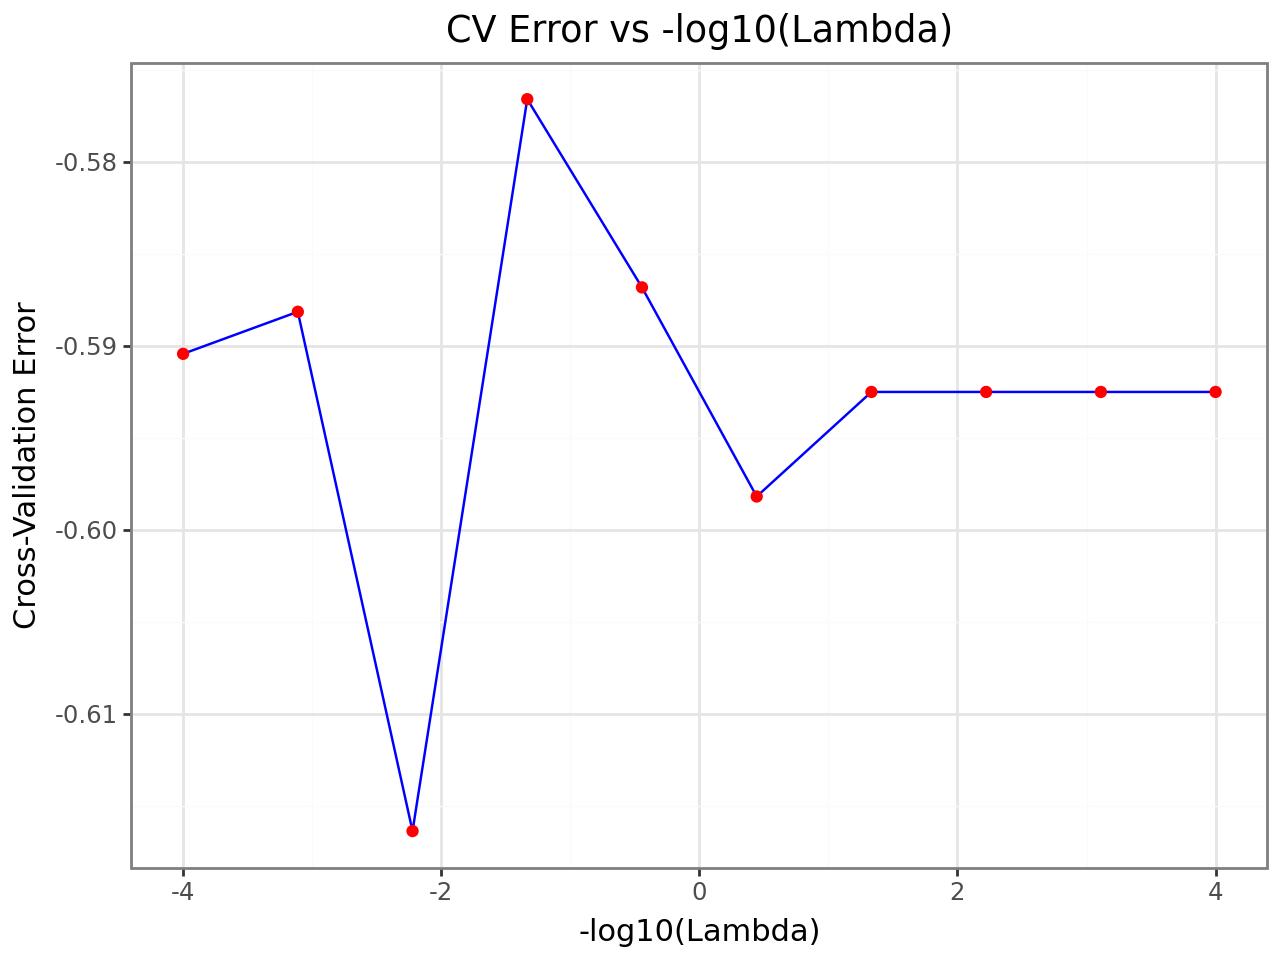

In [11]:

train_tdf = tdf.mutate({
    "log10members": lambda x: np.log10(x["members"]),
    "score_label": lambda x: np.where(x["score"] >= 7.5, "Hit!", "No hit...")
})
clean_tdf = train_tdf.drop_na(["log10members", "episodes", "popularity", "year", "score_label"])

x = clean_tdf.select(["log10members", "episodes", "popularity", "year"]).to_pandas().to_numpy()
y = clean_tdf.select("score_label").to_pandas().to_numpy().ravel()


lambdas = np.logspace(-4, 4, 10)
param_grid = {"logistic__C": 1 / lambdas}


scaler = StandardScaler(with_mean=True, with_std=True)
logistic = LogisticRegression(max_iter=1000, warm_start=True)

pipeline = Pipeline([
    ("scaler", scaler),
    ("logistic", logistic)
])


grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(x, y)

print(grid_search.best_params_)
print(grid_search.best_score_)

plot = tidyframe({
    "log_lambda": -np.log10(lambdas),
    "CV_error": -grid_search.cv_results_["mean_test_score"]
    

})

ggplot(plot, aes(x="log_lambda", y="CV_error")) + \
    geom_line(color="blue") + \
    geom_point(color="red") + \
    labs(title="CV Error vs -log10(Lambda)",
            x="-log10(Lambda)",
            y="Cross-Validation Error") + \
    theme_bw()

In [12]:
from sklearn.metrics import confusion_matrix, classification_report



cm = confusion_matrix(y, grid_search.predict(x))
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(y, grid_search.predict(x)))

Confusion Matrix:
[[432  87]
 [242 118]]
Classification Report:
              precision    recall  f1-score   support

        Hit!       0.64      0.83      0.72       519
   No hit...       0.58      0.33      0.42       360

    accuracy                           0.63       879
   macro avg       0.61      0.58      0.57       879
weighted avg       0.61      0.63      0.60       879



Well this doesnt look great. The accuracy is only 63%. However the model seems to better predect Hit than no hit. Anime is subjective, as the scatterplots show the data is noisy and spread out. So it makes sense.

In [13]:
best = grid_search.best_estimator_
best_model = best.named_steps["logistic"]
best_model 


,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(0....4842503189421)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:




dummy_anime1 = np.array([[4.5, 12, 5000, 2015]])  # log10members, episodes, popularity, year
dummy_anime2 = np.array([[6.0, 50, 200, 2020]])    
dummy_anime3 = np.array([[5.0, 24, 1000, 2010]])    
dummy_anime4 = np.array([[3.5, 6, 10000, 2005]])    

print("Anime1: Miku's Adventure Prediction:", best.predict(dummy_anime1)[0])
print("Predicted probability of being a hit?", best.predict_proba(dummy_anime1)[0])
print("-" * 50)
print("Anime2: Samurai Quest Prediction:", best.predict(dummy_anime2)[0])
print("Predicted probability of being a hit?", best.predict_proba(dummy_anime2)[0])
print("-" * 50)
print("Anime3: Space Odyssey Prediction:", best.predict(dummy_anime3)[0])
print("Predicted probability of being a hit?", best.predict_proba(dummy_anime3)[0])
print("-" * 50)
print("Anime4: Teto's Bread Bakery Prediction:", best.predict(dummy_anime4)[0])
print("Predicted probability of being a hit?", best.predict_proba(dummy_anime4)[0])


Anime1: Miku's Adventure Prediction: No hit...
Predicted probability of being a hit? [0.02701664 0.97298336]
--------------------------------------------------
Anime2: Samurai Quest Prediction: Hit!
Predicted probability of being a hit? [0.71056632 0.28943368]
--------------------------------------------------
Anime3: Space Odyssey Prediction: No hit...
Predicted probability of being a hit? [0.36255853 0.63744147]
--------------------------------------------------
Anime4: Teto's Bread Bakery Prediction: No hit...
Predicted probability of being a hit? [4.88081817e-04 9.99511918e-01]


Unfortunately the model isnt too accurate. Anime is too subjective for my model to predict well! So I will try another model, I know we havent covered this in class but let me cook. I will use RandomTreeClassifier.

c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:860: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.


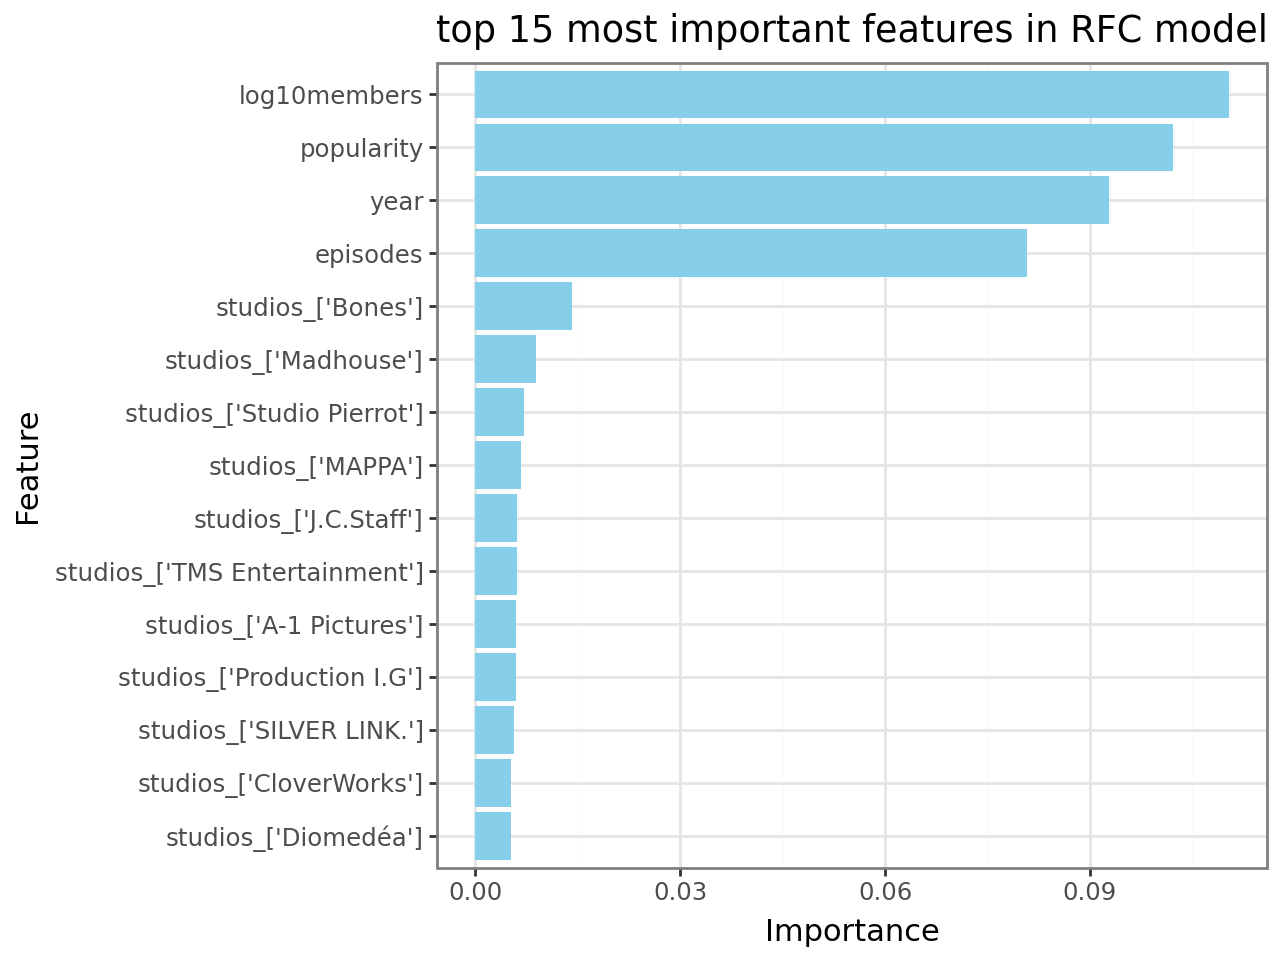

In [ ]:
train_tdf = tdf.mutate({
    "log10members": lambda x: np.log10(x["members"]),
    "score_label": lambda x: np.where(x["score"] >= 7.5, "Hit!", "No hit...")
})
clean_tdf = train_tdf.drop_na(["log10members", "episodes", "popularity", "year", "genres", "studios", "score_label"])
x = clean_tdf.select(["log10members", "episodes", "popularity", "year", "genres", "studios"]).to_pandas()
y = clean_tdf.select("score_label").to_pandas().to_numpy().ravel()

numeric_features = ["log10members", "episodes", "popularity", "year"]
categorical_features = ["genres", "studios"]

num = "passthrough"
categorial_transforming = OneHotEncoder(handle_unknown="ignore")

pp = ColumnTransformer(
    transformers=[
        ("num", num, numeric_features),
        ("cat", categorial_transforming, categorical_features)
    ]
)

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, warm_start=True, class_weight="balanced", max_depth=None)
pipeline = Pipeline([
    ("preprocessing", pp),
    ("classifier", rf)
])

pipeline.fit(xtrain, ytrain)


rf_model = pipeline.named_steps["classifier"]
preprocessor = pipeline.named_steps["preprocessing"]
numeric_features = ["log10members", "episodes", "popularity", "year"]
categorical_features = preprocessor.transformers_[1][1].get_feature_names_out(categorical_features)


all_features = np.concatenate([numeric_features, categorical_features])


importances = rf_model.feature_importances_


feat_df = pd.DataFrame({ # tidypandas doesnt have a built in sort method that allows to propely display the graph. Please allow me to use pandas JUST for plotting the graph
    "Feature": all_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)
(
    ggplot(feat_df.head(15), aes(x="reorder(Feature, Importance)", y="Importance"))
    + geom_col(fill="skyblue")
    + coord_flip()
    + labs(
        title="top 15 most important features in RFC model",
        x="Feature",
        y="Importance"
    )
    + theme_bw()
)

As seen in the plot, log10members, popularity, year and episodes are the most important features to predicting whether an anime is a "Hit!" or "No hit...".
Studios such as Bones, Madhouse, MAPPA also directly influence the model's predictions, indicating that certain studios consistently produce higher-rated anime.

In [16]:
cm = confusion_matrix(ytest, pipeline.predict(xtest))
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(ytest, pipeline.predict(xtest)))


Confusion Matrix:
[[83 21]
 [23 49]]
Classification Report:
              precision    recall  f1-score   support

        Hit!       0.78      0.80      0.79       104
   No hit...       0.70      0.68      0.69        72

    accuracy                           0.75       176
   macro avg       0.74      0.74      0.74       176
weighted avg       0.75      0.75      0.75       176



As seen here, the confusion matrix and accuracy show this model is better at predicting Hit and No hit because RandomForestClassifier can handle complex relationships and feature interactions better than Logistic Regression.
Accuracy is 75% compared to 63% before.

The final model will be unsupervised learning. I will use Kmeans and Principal component analysis (PCA) to cluster anime based on their features. 


c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\tidy_utils.py:211: FutureWarning: RangeIndex.is_numeric is deprecated. Use pandas.api.types.is_any_real_numeric_dtype instead


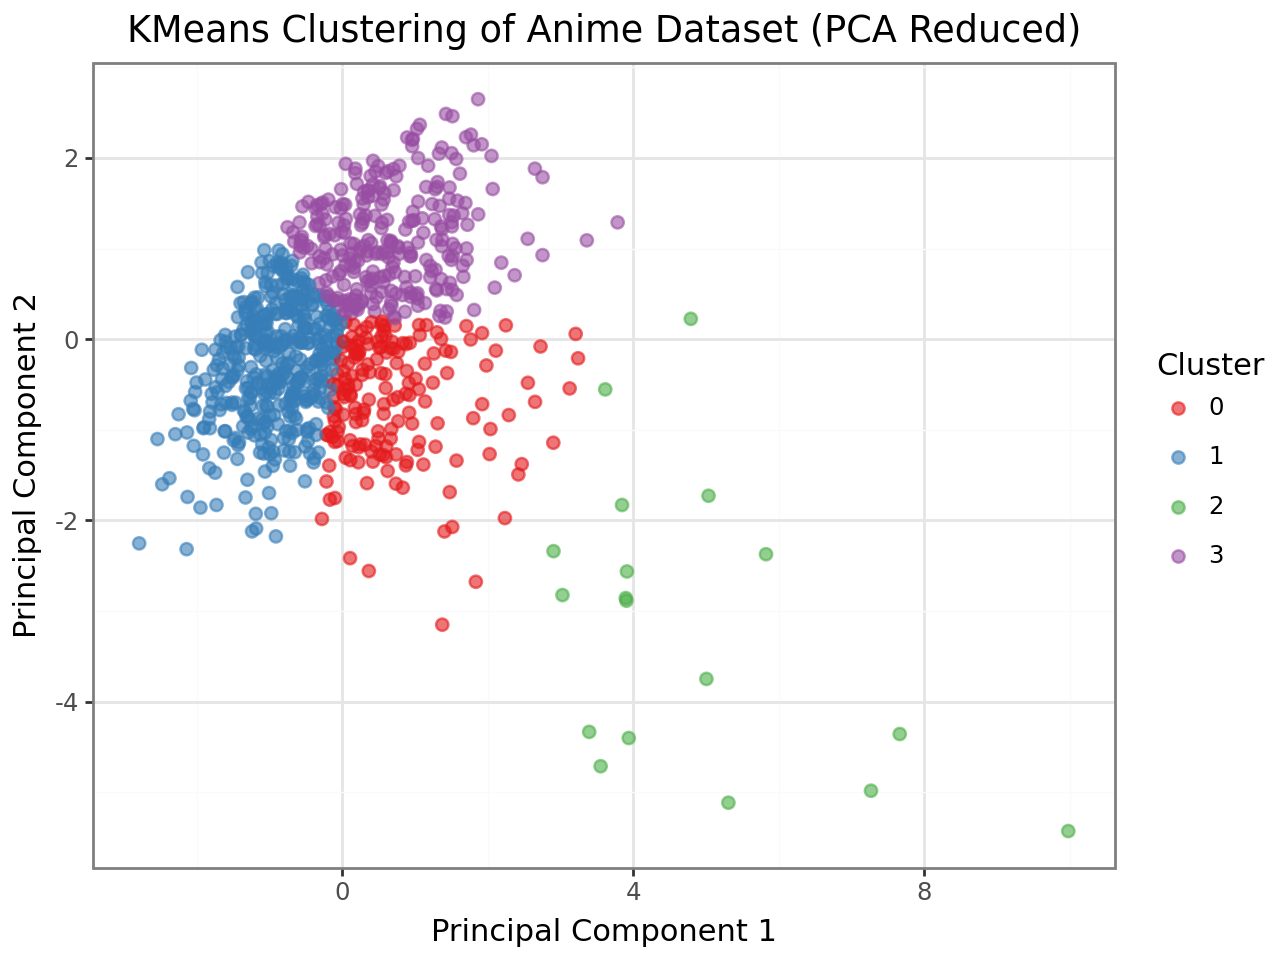

In [17]:
clustering_columns = ["log10members", "episodes", "year", "score"]

cluster_tdf = (
    tdf.mutate({
        "log10members": lambda x: np.log10(x["members"])
    })
    .select(clustering_columns)
    .drop_na()
    .to_pandas()
)

scaler = StandardScaler(with_mean=True, with_std=True)
scaled_data = scaler.fit_transform(cluster_tdf)

pca = PCA(n_components=2)
principalscaled = pca.fit_transform(scaled_data)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(principalscaled)

tdf_plotting = tidyframe({
    "PC1": principalscaled[:, 0],
    "PC2": principalscaled[:, 1],
    "Cluster": clusters.astype(str)
})

(ggplot(tdf_plotting, aes(x="PC1", y="PC2", color="Cluster"))
        + geom_point(alpha=0.6, size=2)
 + labs(
     title="KMeans Clustering of Anime Dataset (PCA Reduced)",
     x="Principal Component 1",
     y="Principal Component 2"
 )
 + theme_bw()
 + scale_color_brewer(type="qual", palette="Set1")
)

In [20]:
cluster_tdf2 = tidyframe({
    "log10members": cluster_tdf["log10members"].tolist(),
    "episodes": cluster_tdf["episodes"].tolist(),
    "year": cluster_tdf["year"].tolist(),
    "score": cluster_tdf["score"].tolist(),
    "Cluster": clusters.tolist()
})




summary = cluster_tdf2.summarize({
    "avg_log10members": "x['log10members'].mean()",
    "avg_episodes": "x['episodes'].mean()",
    "avg_year": "x['year'].mean()",
    "avg_score": "x['score'].mean()"
}, by=["Cluster"])

summary


c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\tidy_utils.py:211: FutureWarning: RangeIndex.is_numeric is deprecated. Use pandas.api.types.is_any_real_numeric_dtype instead
c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\tidyframe_class.py:1054: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
c:\Users\wagne\AppData\Local\Programs\Python\Python313\Lib\site-packages\tidypandas\format.py:166: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.


,Cluster,avg_log10members,avg_episodes,avg_year,avg_score
,<int64>,<float64>,<float64>,<float64>,<float64>
0,3,6.002911,16.615385,2017.505495,8.186300
1,2,6.006764,214.166667,2001.166667,8.003889
2,0,5.747723,26.352601,2007.658960,7.783988
3,1,5.602976,13.050602,2017.465060,7.164795


I performed four clusterings. The first cluster is cluster 0, is red. The summary tdf, it is popular, modern anime with higher scoring. The clusterings is packed together in the scatterplot. 
Cluster 1 is blue. It is older anime with about same popularity but has slightly lower scoring. However it has MUCH higher episode counts. The clusterings are tightly packed. 
Cluster 2 is green. Woah, it's super spread out, that means there's a lot of outliers. The average episode count is high, it is decently old, 2007ish, and score is second lowest. 
Cluster 3 is purple. It has the least popularity, episode counts and average score. The anime is modern like cluster 0. They're packed together.

**5. [10%]** Reflect upon your findings from this assignment and articulate the strengths and weaknesses of your approach. Discuss future directions that could be followed up from your study.

This was a fun mini project to do. The strengths are it shows my analysis shows my EDA showed patterns I built. My analyis proved membership count and score DO relate, Episode count and year not much though. Supervised learning, especially linear, can be hit or miss.
My strengths are: My models are built from each other. RFC was much better at predicting than LogisticRegression. Kmeans and PCA showed structure without labeling, it helped grouped anime based on popularity age and score.

My weaknesses are: Felt like i didnt explore enough. I only used simple numeric features. Didnt go deeper such as genres or community trends. LogisticRegression was proven unreliable. My dummy anime werent predicted well. Clustering also depends on PCA.

But this was a fun, I enjoyed this. Future directions include more analysis and exploring many models scikit-learn can offer. I learned a lot on this class, and I look forward to do more data analysis and machine learning.

**Exporting this Python notebook to HTML.** We have reviewed in class how to export a Python notebook to HTML. However, for a reminder, you can see the following [answer](https://stackoverflow.com/questions/53460051/convert-ipynb-notebook-to-html-in-google-colab) on Stack Overflow as a reminder. You can use the Python notebook cell below to paste in the code to export to HTML.